# GP Spectral Mixture Tutorial

Purpose: model multi-frequency vibration-like signals where simple kernels underfit periodic structure.


## Learning Roadmap

- See why spectral mixture kernels help for multi-frequency signals.
- Compare fit quality and uncertainty in extrapolation regions.
- Inspect frequency-domain behavior of predictions.


In [1]:
# Step 1: import spectral mixture GP and utilities
# Configure Python path for local package imports
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parents[1] if Path.cwd().name == 'gp' else Path.cwd().resolve()
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

import math
import time
import numpy as np
import torch
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
torch.manual_seed(42)
np.random.seed(42)

from deepuq.models import SpectralMixtureGaussianProcessRegressor


In [2]:
# Step 2: define calibration metrics
def regression_metrics(y_true, mean, var):
    y_true = y_true.reshape(-1)
    mean = mean.reshape(-1)
    var = var.reshape(-1).clamp_min(1e-8)
    rmse = torch.sqrt(torch.mean((mean - y_true) ** 2)).item()
    nll = 0.5 * torch.mean(torch.log(2 * torch.pi * var) + (y_true - mean) ** 2 / var).item()
    std = torch.sqrt(var)
    lower = mean - 1.96 * std
    upper = mean + 1.96 * std
    coverage95 = torch.mean(((y_true >= lower) & (y_true <= upper)).float()).item()
    width95 = torch.mean(upper - lower).item()
    return {
        'rmse': rmse,
        'nll': nll,
        'coverage95': coverage95,
        'interval_width95': width95,
    }


In [3]:
# Step 3: generate multi-frequency vibration-like data
x_train = torch.linspace(-2.5, 2.5, 160).unsqueeze(-1)
true_fn = lambda x: 0.7 * torch.sin(2.0 * x) + 0.45 * torch.sin(5.2 * x + 0.6)
y_train = true_fn(x_train) + 0.08 * torch.randn_like(x_train)

x_test = torch.linspace(-4, 4, 350).unsqueeze(-1)
y_test = true_fn(x_test)


In [4]:
# Step 4: train spectral mixture GP and evaluate metrics
smgp = SpectralMixtureGaussianProcessRegressor(
    num_mixtures=4,
    opt_steps=220,
    lr=0.03,
    noise=0.01,
)
smgp.fit(x_train, y_train)
uq = smgp.predict_uq(x_test)
metrics = regression_metrics(y_test.squeeze(-1), uq.mean, uq.total_var)
print({k: round(v, 4) for k, v in metrics.items()})


{'rmse': 0.2591, 'nll': -0.8346, 'coverage95': 1.0, 'interval_width95': 0.8302}


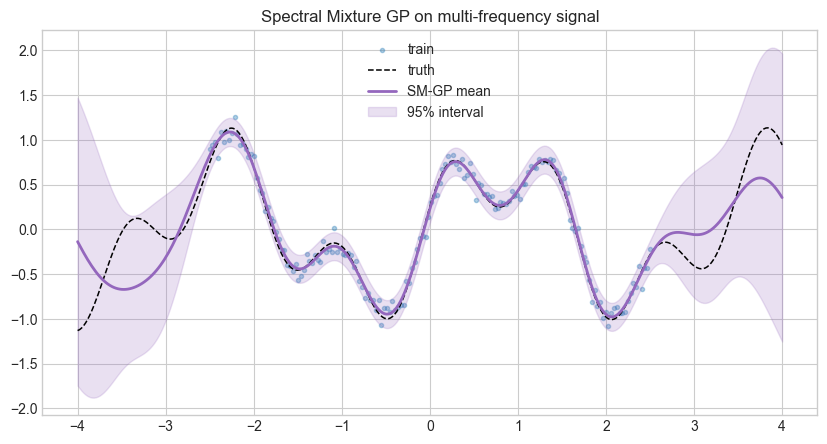

In [5]:
# Step 5: visualize posterior with uncertainty
std = torch.sqrt(uq.total_var)
plt.figure(figsize=(10, 5))
plt.scatter(x_train.numpy(), y_train.numpy(), s=9, alpha=0.35, label='train')
plt.plot(x_test.numpy(), y_test.numpy(), 'k--', lw=1.1, label='truth')
plt.plot(x_test.numpy(), uq.mean.numpy(), color='tab:purple', lw=2, label='SM-GP mean')
plt.fill_between(
    x_test.squeeze(-1).numpy(),
    (uq.mean - 1.96 * std).numpy(),
    (uq.mean + 1.96 * std).numpy(),
    alpha=0.2,
    color='tab:purple',
    label='95% interval',
)
plt.legend(loc='best')
plt.title('Spectral Mixture GP on multi-frequency signal')
plt.show()


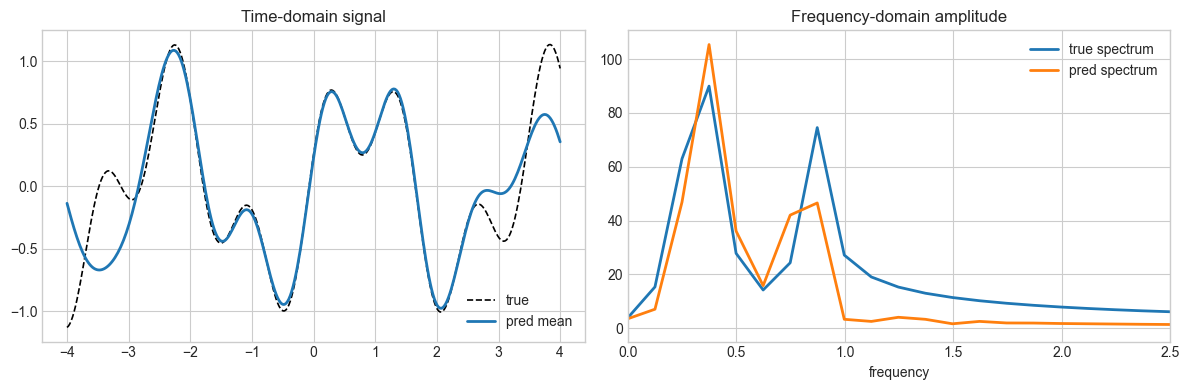

In [6]:
# Additional diagnostic: frequency-domain comparison
# FFT lets us verify that predicted signals preserve major frequency components.
x_np = x_test.squeeze(-1).numpy()
dx = float(x_np[1] - x_np[0])
true_np = y_test.squeeze(-1).numpy()
pred_np = uq.mean.numpy()

freq = np.fft.rfftfreq(len(x_np), d=dx)
amp_true = np.abs(np.fft.rfft(true_np))
amp_pred = np.abs(np.fft.rfft(pred_np))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(x_np, true_np, 'k--', lw=1.2, label='true')
axes[0].plot(x_np, pred_np, lw=2, label='pred mean')
axes[0].set_title('Time-domain signal')
axes[0].legend(loc='best')

axes[1].plot(freq, amp_true, lw=2, label='true spectrum')
axes[1].plot(freq, amp_pred, lw=2, label='pred spectrum')
axes[1].set_xlim(0, 2.5)
axes[1].set_title('Frequency-domain amplitude')
axes[1].set_xlabel('frequency')
axes[1].legend(loc='best')
plt.tight_layout()
plt.show()
